In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

temp = pd.read_csv("data/temperature.csv")
temp.head()

,datetime,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
0,2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN
1,2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,...,285.630000,288.220000,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5
2,2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,...,285.663208,288.247676,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5
3,2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,...,285.756824,288.326940,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5
4,2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,...,285.850440,288.406203,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5


In [2]:
temp.info()
temp.isnull().sum().head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45253 entries, 0 to 45252
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           45253 non-null  object 
 1   Vancouver          44458 non-null  float64
 2   Portland           45252 non-null  float64
 3   San Francisco      44460 non-null  float64
 4   Seattle            45250 non-null  float64
 5   Los Angeles        45250 non-null  float64
 6   San Diego          45252 non-null  float64
 7   Las Vegas          45252 non-null  float64
 8   Phoenix            45250 non-null  float64
 9   Albuquerque        45252 non-null  float64
 10  Denver             45252 non-null  float64
 11  San Antonio        45252 non-null  float64
 12  Dallas             45249 non-null  float64
 13  Houston            45250 non-null  float64
 14  Kansas City        45252 non-null  float64
 15  Minneapolis        45240 non-null  float64
 16  Saint Louis        452

datetime           0
Vancouver        795
Portland           1
San Francisco    793
Seattle            3
dtype: int64

In [3]:
temp['datetime'] = pd.to_datetime(temp['datetime'])
temp.set_index('datetime', inplace=True)

In [4]:
temp = temp.fillna(method='ffill')  # forward fill (best for time-series)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\2907222252.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp = temp.fillna(method='ffill')  # forward fill (best for time-series)


In [ ]:
city = 'New York' 
df = temp[[city]]
df.rename(columns={city: 'temperature'}, inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\60737094.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={city: 'temperature'}, inplace=True)


In [6]:
daily_temp = df.resample('D').mean()

In [7]:
monthly_temp = df.resample('M').mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\2311648254.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample('M').mean()


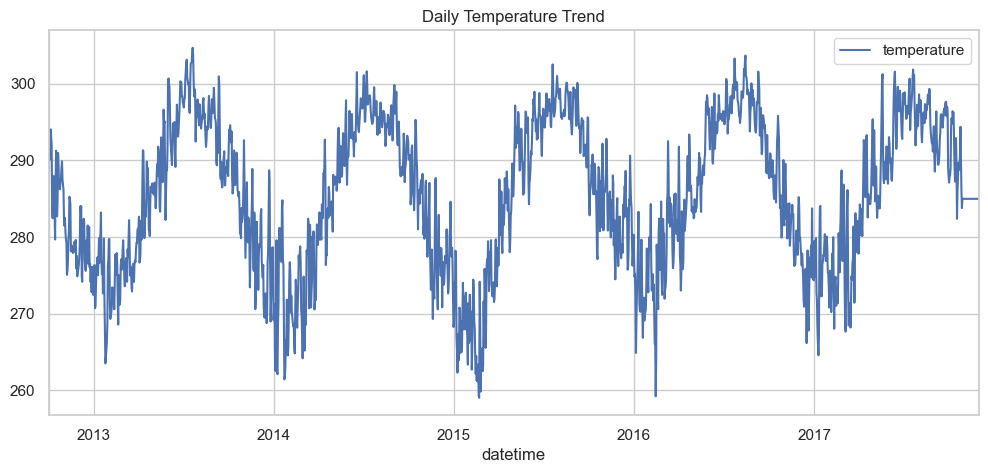

In [8]:
daily_temp.plot(figsize=(12,5))
plt.title("Daily Temperature Trend")
plt.show()

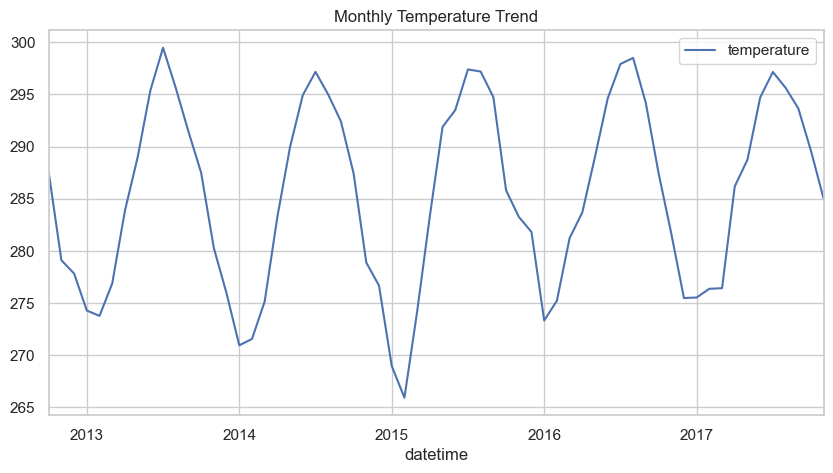

In [9]:
monthly_temp.plot(figsize=(10,5))
plt.title("Monthly Temperature Trend")
plt.show()

In [11]:
print("Max Temp:", df['temperature'].max())
print("Min Temp:", df['temperature'].min())

Max Temp: 310.24
Min Temp: 250.774


In [12]:
df['month'] = df.index.month
monthly_pattern = df.groupby('month')['temperature'].mean()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\3796009440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df.index.month


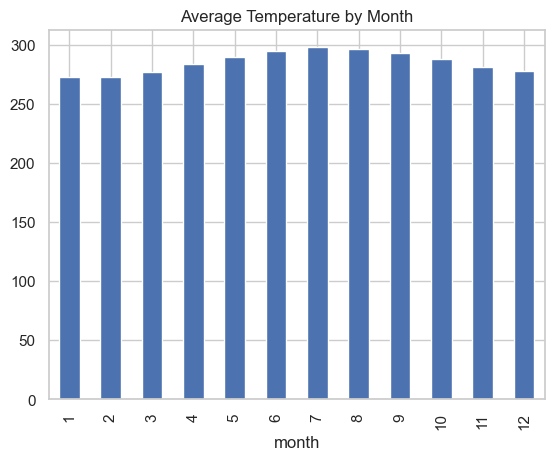

In [13]:
monthly_pattern.plot(kind='bar')
plt.title("Average Temperature by Month")
plt.show()

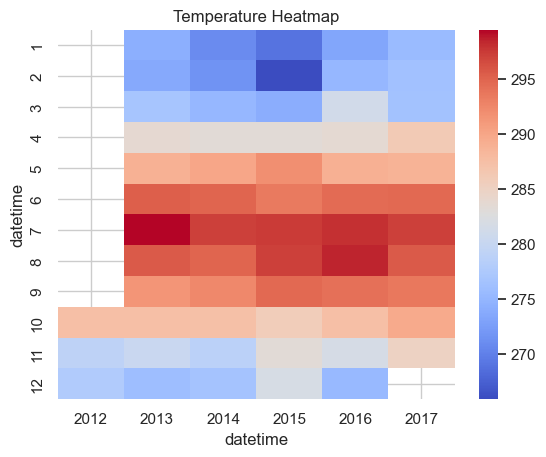

In [14]:
pivot = df.pivot_table(values='temperature',
                       index=df.index.month,
                       columns=df.index.year)

sns.heatmap(pivot, cmap='coolwarm')
plt.title("Temperature Heatmap")
plt.show()

In [15]:
humidity = pd.read_csv("data/humidity.csv")
humidity['datetime'] = pd.to_datetime(humidity['datetime'])
humidity.set_index('datetime', inplace=True)

humidity = humidity.fillna(method='ffill')

humidity_city = humidity[[city]]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\1093228328.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  humidity = humidity.fillna(method='ffill')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_16012\3857276749.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  humidity_city.resample('M').mean().plot()


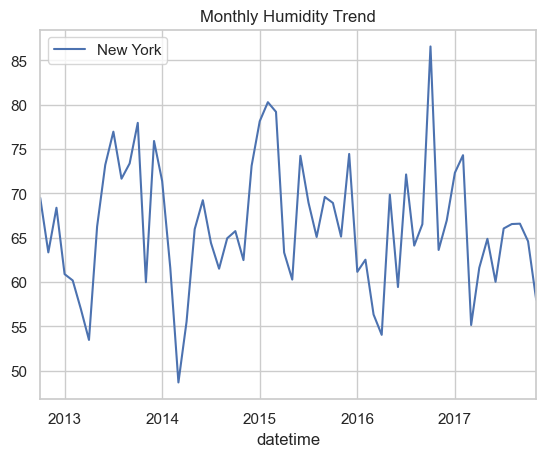

In [16]:
humidity_city.resample('M').mean().plot()
plt.title("Monthly Humidity Trend")
plt.show()

In [20]:
print("Max Temp:", df['temperature'].max())
print("Min Temp:", df['temperature'].min())

Max Temp: 310.24
Min Temp: 250.774


In [21]:
monthly_pattern.head()
print(df['temperature'].max())
print(df['temperature'].min())

310.24
250.774
